In [51]:
# Импорт необходимых библиотек
import numpy as np
import scipy.stats as st
import pandas as pd
import matplotlib.pyplot as plt

# Фиксация seed для воспроизводимости результатов
np.random.seed(42)

In [52]:
# Вспомогательные функции для работы с распределением Парето

def inv_pareto(u, theta):
    """
    Обратная функция распределения (квантильная функция) для Парето
    p(x) = (theta-1)/x^theta, x >= 1, theta > 1
    """
    return (1 - u) ** (1 / (1 - theta))


def median_pareto(theta):
    """
    Теоретическая медиана распределения Парето
    """
    return 2 ** (1 / (theta - 1))


def mle_theta(sample):
    """
    Оценка максимального правдоподобия для параметра theta
    theta_hat = 1 + n / sum(ln(x_i))
    """
    n = len(sample)
    return 1 + n / np.sum(np.log(sample))

## Пункт d: Генерация выборки и вычисление доверительных интервалов

In [53]:
# Параметры для генерации выборки
n = 100  # объем выборки
theta_true = 5  # истинное значение параметра
conf_level = 0.95  # доверительная вероятность

# Генерация выборки из распределения Парето
u_sample = np.random.uniform(0, 1, n)
x_sample = inv_pareto(u_sample, theta_true)

# Вычисление оценки максимального правдоподобия
theta_hat = mle_theta(x_sample)
median_hat = median_pareto(theta_hat)
median_true = median_pareto(theta_true)

print(f"Истинное значение theta: {theta_true}")
print(f"Оценка theta (MLE): {theta_hat:.5f}")
print(f"Истинная медиана: {median_true:.5f}")
print(f"Оценка медианы: {median_hat:.5f}")

Истинное значение theta: 5
Оценка theta (MLE): 5.37279
Истинная медиана: 1.18921
Оценка медианы: 1.17177


In [54]:
# Асимптотический доверительный интервал для медианы

z_low = st.norm.ppf((1 - conf_level) / 2)
z_high = st.norm.ppf((1 + conf_level) / 2)

# Вычисление стандартной ошибки для медианы
se_median = median_hat * np.log(2) / (np.sqrt(n) * (theta_hat - 1))

# Границы доверительного интервала
ci_median_lower = median_hat + z_low * se_median
ci_median_upper = median_hat + z_high * se_median
ci_median_length = ci_median_upper - ci_median_lower

print("=" * 60)
print("АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ МЕДИАНЫ")
print("=" * 60)
print(f"Границы интервала: ({ci_median_lower:.5f}, {ci_median_upper:.5f})")
print(f"Длина интервала: {ci_median_length:.5f}")
print(f"Содержит истинную медиану: {ci_median_lower <= median_true <= ci_median_upper}")

АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ МЕДИАНЫ
Границы интервала: (1.13536, 1.20817)
Длина интервала: 0.07281
Содержит истинную медиану: True


In [55]:
# Асимптотический доверительный интервал для параметра theta

se_theta = (theta_hat - 1) / np.sqrt(n)

# Границы доверительного интервала
ci_theta_asym_lower = theta_hat + z_low * se_theta
ci_theta_asym_upper = theta_hat + z_high * se_theta
ci_theta_asym_length = ci_theta_asym_upper - ci_theta_asym_lower

print("=" * 60)
print("АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ THETA")
print("=" * 60)
print(f"Границы интервала: ({ci_theta_asym_lower:.5f}, {ci_theta_asym_upper:.5f})")
print(f"Длина интервала: {ci_theta_asym_length:.5f}")
print(f"Содержит истинное theta: {ci_theta_asym_lower <= theta_true <= ci_theta_asym_upper}")

АСИМПТОТИЧЕСКИЙ ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ ДЛЯ THETA
Границы интервала: (4.51574, 6.22984)
Длина интервала: 1.71410
Содержит истинное theta: True


## Пункт e(t): Бутстраповские доверительные интервалы

In [56]:
# Непараметрический бутстрап

B = 1000  # количество бутстрап-выборок

# Генерация индексов для бутстрап-выборок (размер B x n)
bootstrap_indices = np.random.randint(0, n, size=(B, n))

# Формирование бутстрап-выборок
x_bootstrap_np = x_sample[bootstrap_indices]

# Вычисление оценок theta для всех бутстрап-выборок
sum_logs_np = np.sum(np.log(x_bootstrap_np), axis=1)
theta_bootstrap_np = 1 + n / sum_logs_np

# Метод процентилей для построения доверительного интервала
alpha = 1 - conf_level
ci_theta_np_lower = np.percentile(theta_bootstrap_np, 100 * alpha / 2)
ci_theta_np_upper = np.percentile(theta_bootstrap_np, 100 * (1 - alpha / 2))
ci_theta_np_length = ci_theta_np_upper - ci_theta_np_lower

print("=" * 60)
print("НЕПАРАМЕТРИЧЕСКИЙ БУТСТРАП (для theta)")
print("=" * 60)
print(f"Границы интервала: ({ci_theta_np_lower:.5f}, {ci_theta_np_upper:.5f})")
print(f"Длина интервала: {ci_theta_np_length:.5f}")
print(f"Содержит истинное theta: {ci_theta_np_lower <= theta_true <= ci_theta_np_upper}")

НЕПАРАМЕТРИЧЕСКИЙ БУТСТРАП (для theta)
Границы интервала: (4.66925, 6.37030)
Длина интервала: 1.70105
Содержит истинное theta: True


In [57]:
# Параметрический бутстрап
# Генерируем выборки из распределения Парето с параметром theta_hat

B = 1000  # количество бутстрап-выборок

# Генерация равномерных случайных величин (размер B x n)
u_bootstrap = np.random.uniform(0, 1, size=(B, n))

# Преобразование в выборки из Парето(theta_hat)
x_bootstrap_p = inv_pareto(u_bootstrap, theta_hat)

# Вычисление оценок theta для всех бутстрап-выборок
sum_logs_p = np.sum(np.log(x_bootstrap_p), axis=1)
theta_bootstrap_p = 1 + n / sum_logs_p

# Метод процентилей для построения доверительного интервала
alpha = 1 - conf_level
ci_theta_p_lower = np.percentile(theta_bootstrap_p, 100 * alpha / 2)
ci_theta_p_upper = np.percentile(theta_bootstrap_p, 100 * (1 - alpha / 2))
ci_theta_p_length = ci_theta_p_upper - ci_theta_p_lower

print("=" * 60)
print("ПАРАМЕТРИЧЕСКИЙ БУТСТРАП (для theta)")
print("=" * 60)
print(f"Границы интервала: ({ci_theta_p_lower:.5f}, {ci_theta_p_upper:.5f})")
print(f"Длина интервала: {ci_theta_p_length:.5f}")
print(f"Содержит истинное theta: {ci_theta_p_lower <= theta_true <= ci_theta_p_upper}")

ПАРАМЕТРИЧЕСКИЙ БУТСТРАП (для theta)
Границы интервала: (4.67930, 6.30301)
Длина интервала: 1.62370
Содержит истинное theta: True


## Пункт f: Сравнение всех доверительных интервалов

In [58]:
# Создание таблицы для сравнения всех методов

methods_data = {
    'Метод': [
        'Асимптотический',
        'Бутстрап (непараметрический)',
        'Бутстрап (параметрический)'
    ],
    'Нижняя граница': [
        ci_theta_asym_lower,
        ci_theta_np_lower,
        ci_theta_p_lower
    ],
    'Верхняя граница': [
        ci_theta_asym_upper,
        ci_theta_np_upper,
        ci_theta_p_upper
    ],
    'Длина интервала': [
        ci_theta_asym_length,
        ci_theta_np_length,
        ci_theta_p_length
    ],
    'Содержит theta_true': [
        ci_theta_asym_lower <= theta_true <= ci_theta_asym_upper,
        ci_theta_np_lower <= theta_true <= ci_theta_np_upper,
        ci_theta_p_lower <= theta_true <= ci_theta_p_upper
    ]
}

df_comparison = pd.DataFrame(methods_data)

print("\n" + "=" * 80)
print("СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ ДЛЯ THETA")
print("=" * 80)
print(df_comparison.to_string(index=False))


СРАВНЕНИЕ ДОВЕРИТЕЛЬНЫХ ИНТЕРВАЛОВ ДЛЯ THETA
                       Метод  Нижняя граница  Верхняя граница  Длина интервала  Содержит theta_true
             Асимптотический        4.515738         6.229840         1.714102                 True
Бутстрап (непараметрический)        4.669250         6.370302         1.701052                 True
  Бутстрап (параметрический)        4.679304         6.303007         1.623704                 True


In [59]:
# Ранжирование методов по длине доверительного интервала
# (меньшая длина при правильном покрытии - лучше)

intervals = [
    (ci_theta_asym_length, 'Асимптотический', ci_theta_asym_lower, ci_theta_asym_upper),
    (ci_theta_np_length, 'Бутстрап (непараметрический)', ci_theta_np_lower, ci_theta_np_upper),
    (ci_theta_p_length, 'Бутстрап (параметрический)', ci_theta_p_lower, ci_theta_p_upper)
]

# Сортировка по длине интервала
intervals_sorted = sorted(intervals, key=lambda x: x[0])

print("\n" + "=" * 60)
print("РАНЖИРОВАНИЕ МЕТОДОВ (по возрастанию длины интервала)")
print("=" * 60)

for i, (length, name, lower, upper) in enumerate(intervals_sorted, 1):
    covers = "✓" if (lower <= theta_true <= upper) else "✗"
    print(f"{i}. {name}")
    print(f"   Длина: {length:.5f}")
    print(f"   Интервал: ({lower:.5f}, {upper:.5f})")
    print(f"   Содержит истинное theta: {covers}")
    print()


РАНЖИРОВАНИЕ МЕТОДОВ (по возрастанию длины интервала)
1. Бутстрап (параметрический)
   Длина: 1.62370
   Интервал: (4.67930, 6.30301)
   Содержит истинное theta: ✓

2. Бутстрап (непараметрический)
   Длина: 1.70105
   Интервал: (4.66925, 6.37030)
   Содержит истинное theta: ✓

3. Асимптотический
   Длина: 1.71410
   Интервал: (4.51574, 6.22984)
   Содержит истинное theta: ✓



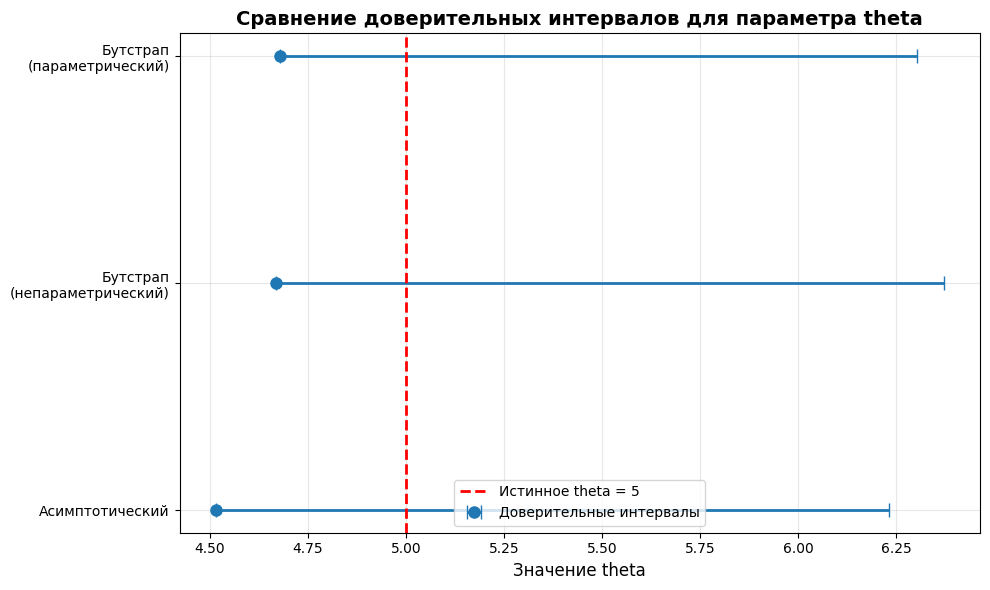

In [60]:
# Визуализация доверительных интервалов

fig, ax = plt.subplots(figsize=(10, 6))

methods = ['Асимптотический', 'Бутстрап\n(непараметрический)', 'Бутстрап\n(параметрический)']
lower_bounds = [ci_theta_asym_lower, ci_theta_np_lower, ci_theta_p_lower]
upper_bounds = [ci_theta_asym_upper, ci_theta_np_upper, ci_theta_p_upper]
y_pos = np.arange(len(methods))

# Построение интервалов
ax.errorbar(lower_bounds, y_pos, xerr=[np.array(lower_bounds) - np.array(lower_bounds), 
                                        np.array(upper_bounds) - np.array(lower_bounds)],
            fmt='o', capsize=5, markersize=8, linewidth=2, label='Доверительные интервалы')

# Вертикальная линия для истинного значения theta
ax.axvline(x=theta_true, color='red', linestyle='--', linewidth=2, label=f'Истинное theta = {theta_true}')

ax.set_yticks(y_pos)
ax.set_yticklabels(methods)
ax.set_xlabel('Значение theta', fontsize=12)
ax.set_title('Сравнение доверительных интервалов для параметра theta', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()